## Step 0


In [2]:
import pandas as pd
import numpy as np  # All the libraries that we need are in this section
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



In [3]:
df_raw = pd.read_csv("data/symbol_info_3-25.csv")

# Make a copy of the original dataset with the codintions given at setp 0 
df = df_raw[
    (df_raw["is_etf"] == 0)&
    (df_raw["is_fund"] == 0)&
    (df_raw["is_actively_trading"] == 1)&  
    (df_raw["market_cap"] > 0) &          
    (df_raw["total_revenue"] > 0) &
    (df_raw["sector"] == 'Financial Services')
].copy()


# Changing the scale of the variables  
df["market_cap_b"] = df["market_cap"] / 1e9  
df["revenue_b"] = df["total_revenue"] / 1e9 
df["profit_margin_pct"] = df["profit_margins"] * 100

# Replacing infinite value with NA
df = df.replace([np.inf, -np.inf], np.nan)

# Choosing bold for all titles
plt.rcParams["axes.titleweight"] = "bold"


In [4]:
# Functions used as format of bilions for the axes
def billions_formatter(x, pos):
    return f"{x:,.0f}B"         

def billions_formatter_str(x):
    return f"{x:,.1f}B"   

#f Fucntion to erase usless axes
def clean_spines(ax):
    ax.spines["top"].set_visible(False)       
    ax.spines["right"].set_visible(False)    
    return ax


## Step 1

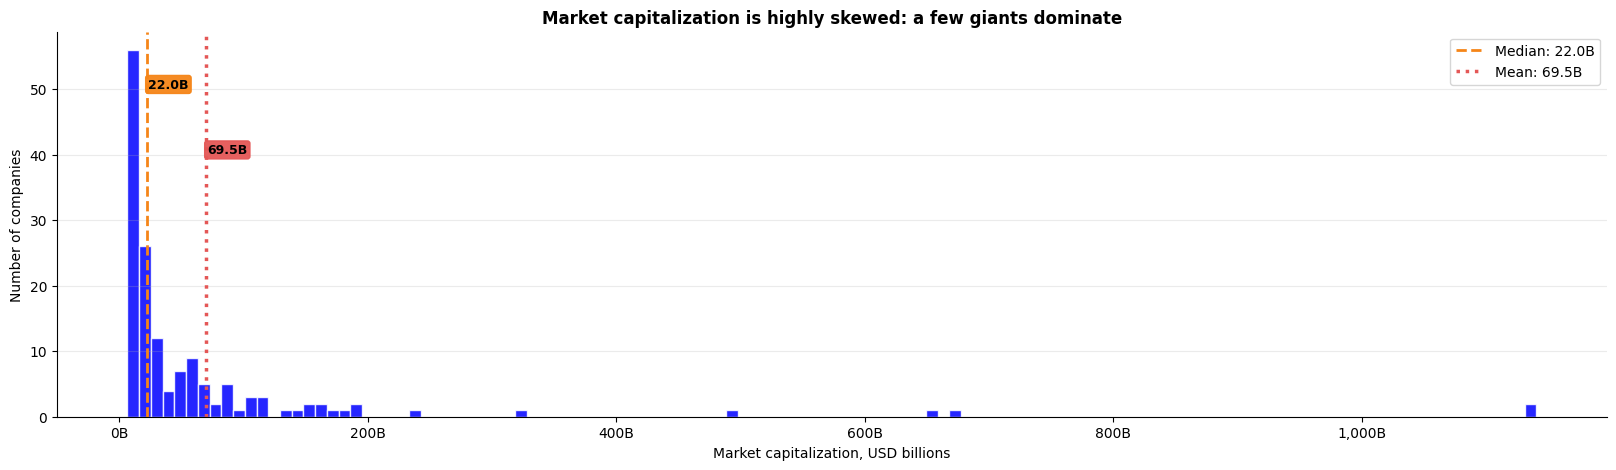

In [5]:

# First we drop NA values
market_cap_b = df["market_cap_b"].dropna() 


# Histogram creation with its properties
fig, ax = plt.subplots(figsize=(20, 5))

ax.hist(
    market_cap_b,          
    bins=120,                
    color="#0000FF",     
    edgecolor="white",  
    alpha=0.85          
    )

# Here we evaluate the median and the mean
mean_value = market_cap_b.mean()
median_value = market_cap_b.median()    

# Creating each vertical line for mean and median
ax.axvline(median_value, color="#F58518", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")   
ax.axvline(mean_value, color="#E45756", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")        

# Rappresenting the value on the histogram near the vertical lines as a text for median and mean 
ax.annotate(
        billions_formatter_str(mean_value),               
        (mean_value,40),                                  
        xytext=(1, 1),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="#E45756",
            ec="#E45756",
            alpha=0.95
        )
)

ax.annotate(
        billions_formatter_str(median_value),
        (median_value,50),
        xytext=(1, 1),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="#F58518",
            ec="#F58518",
            alpha=0.95
        )
)


# Property of the plot
ax.set_title("Market capitalization is highly skewed: a few giants dominate")
ax.set_xlabel("Market capitalization, USD billions")                           # Here we set te title, the axis lable, the grid and the legend
ax.set_ylabel("Number of companies")                                           # in this case we erase the corners that are usless in this plot with clean_spines function
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)
ax.legend()
clean_spines(ax)

plt.show()



## Step 2

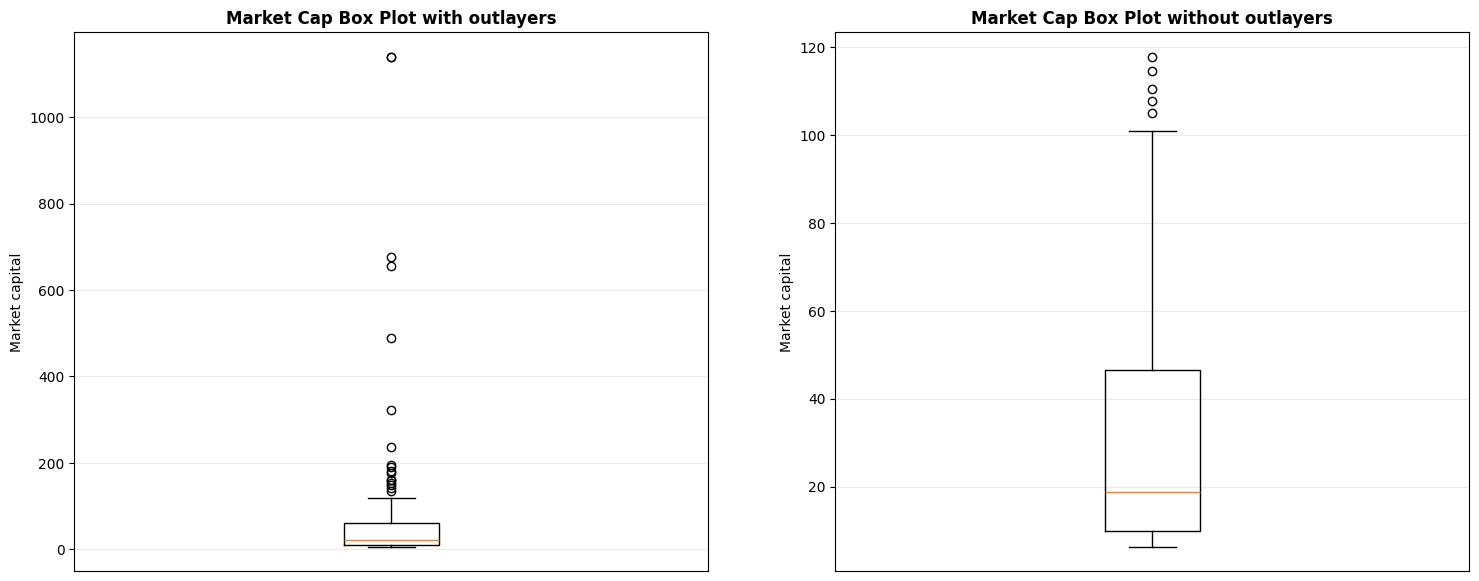

In [6]:
# Evaluating the first, third quantile and the right tick of the box plot
t_quantile = market_cap_b.quantile(0.75)
f_quantile = market_cap_b.quantile(0.25)
out = t_quantile+1.5*(t_quantile-f_quantile)

# We took only the values that are less then the third + 1.5IQR
market_cap_b_wo = market_cap_b[market_cap_b< out] 
                                        
# Creating two subplots
fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize=(18, 7)
)

#Naming the two subplots
ax_mc = axes[0]
ax_mcwo = axes[1]

# Frist boxplot with all the data
ax_mc.boxplot(market_cap_b)
ax_mc.set_title("Market Cap Box Plot with outlayers")
ax_mc.set_ylabel("Market capital")
ax_mc.set_xticks([])
ax_mc.grid(axis="y",alpha=0.25)

# Second box plot without outlayers
ax_mcwo.boxplot(market_cap_b_wo)
ax_mcwo.set_title("Market Cap Box Plot without outlayers")
ax_mcwo.set_ylabel("Market capital")
ax_mcwo.set_xticks([])
ax_mcwo.grid(axis="y",alpha=0.25)


## Step 3


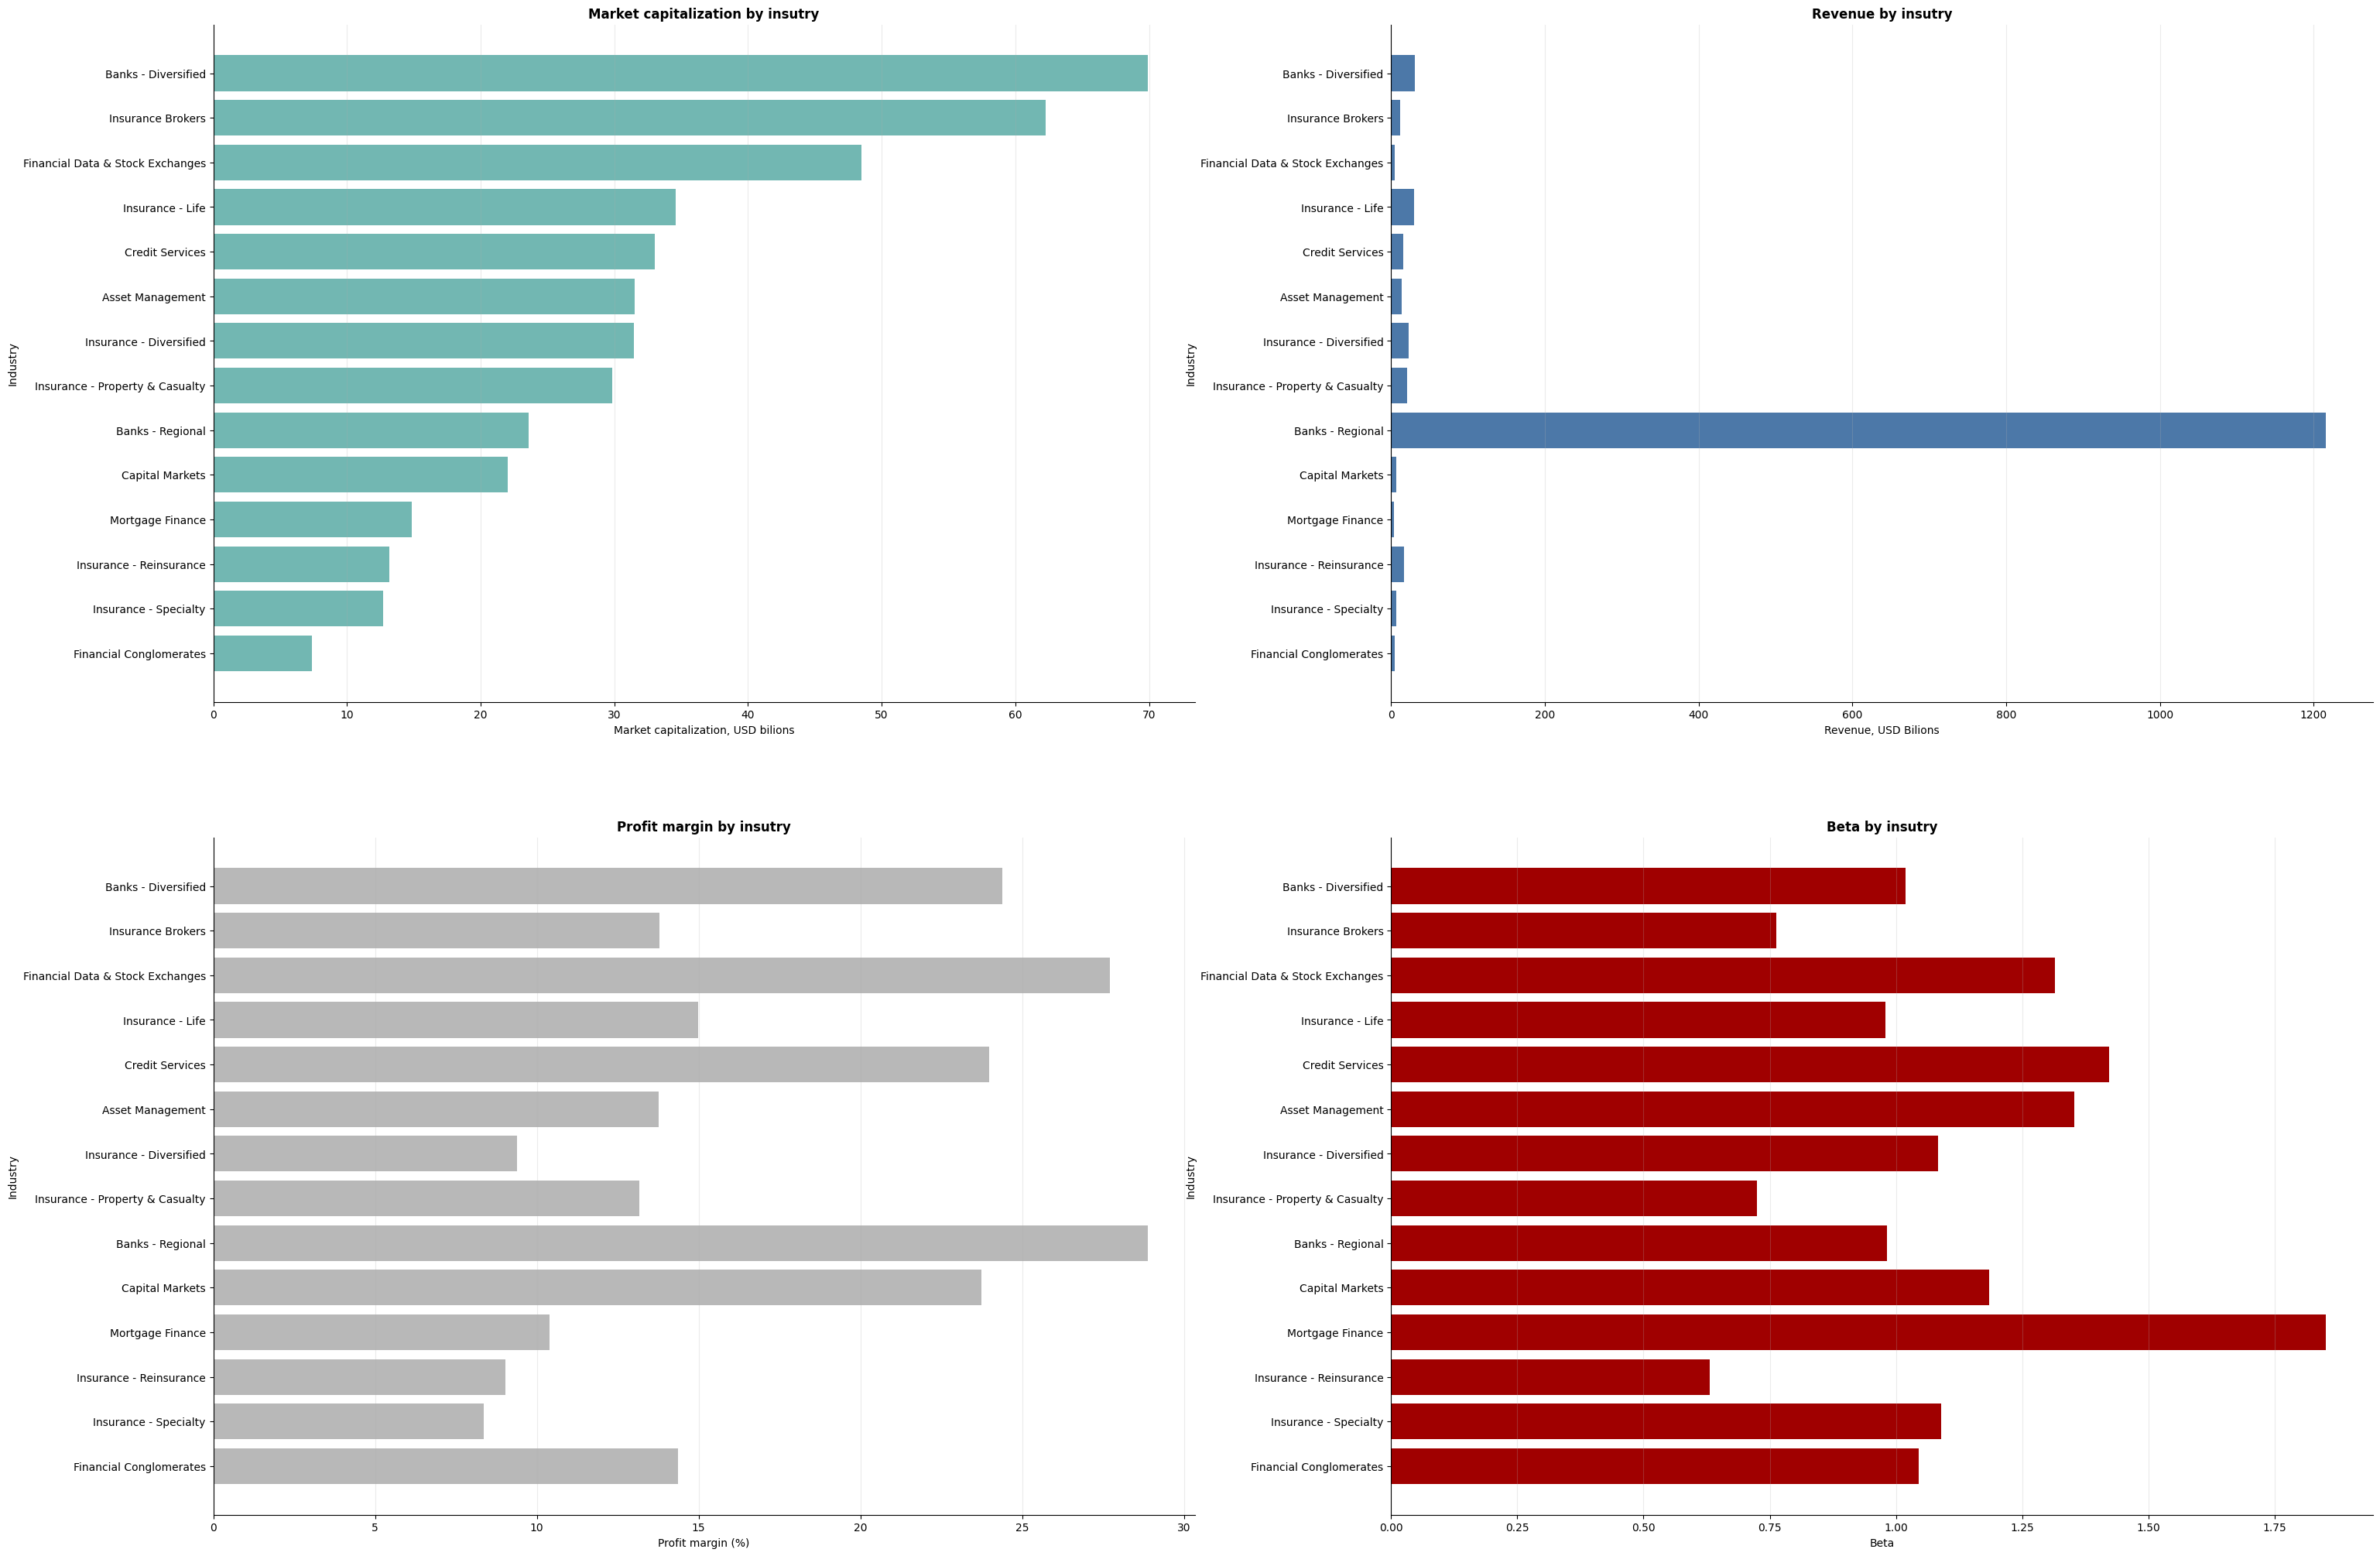

In [7]:
# Exluding outlayer in marcket cap and dropping possible NA values
df_industry = df[df["market_cap_b"]< out].dropna().copy() 

# Changing the NA in sector with Unknow                                        
df_industry["industry_clean"] = df_industry["industry"].fillna("Unknow") 


# We create a new dataframe grouped by industry, with the four features that are required in the step 3 and sorted by mean market capitalization
industry_summary = (df_industry
                    .groupby("industry_clean")
                    .agg(
                        mean_market_cap = ("market_cap_b","mean"),
                        mean_total_revenue = ("revenue_b","mean"),
                        mean_profit_margin = ("profit_margin_pct","mean"),
                        mean_beta = ("beta","mean")
                        )
                        .sort_values("mean_market_cap",ascending=True))

# Creating four subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize = (36,25)
)
# Renaming all subplots
ax_market = axes[0,0]
ax_revenue = axes[0,1]
ax_profit_margin = axes[1,0]
ax_beta = axes[1,1]

# Crating each barh with its properties
ax_market.barh(
    industry_summary.index,
    industry_summary["mean_market_cap"],
    color="#72B7B2"
)
ax_market.set_title("Market capitalization by insutry")
ax_market.set_xlabel("Market capitalization, USD bilions")
ax_market.set_ylabel("Industry")
clean_spines(ax_market)
ax_market.grid(axis="x",alpha = 0.25)


ax_revenue.barh(
    industry_summary.index,
    industry_summary["mean_total_revenue"],
    color="#4C78A8"
)
ax_revenue.set_title("Revenue by insutry")
ax_revenue.set_xlabel("Revenue, USD Bilions")
ax_revenue.set_ylabel("Industry")
clean_spines(ax_revenue)
ax_revenue.grid(axis="x",alpha = 0.25)


ax_profit_margin.barh(
    industry_summary.index,
    industry_summary["mean_profit_margin"],
    color="#b8b8b8"
)
ax_profit_margin.set_title("Profit margin by insutry")
ax_profit_margin.set_xlabel("Profit margin (%)")
ax_profit_margin.set_ylabel("Industry")
clean_spines(ax_profit_margin)
ax_profit_margin.grid(axis="x",alpha = 0.25)

ax_beta.barh(
    industry_summary.index,
    industry_summary["mean_beta"],
    color="#a00000"
)
ax_beta.set_title("Beta by insutry")
ax_beta.set_xlabel("Beta")
ax_beta.set_ylabel("Industry")
clean_spines(ax_beta)
ax_beta.grid(axis="x",alpha = 0.25)


## Step 4


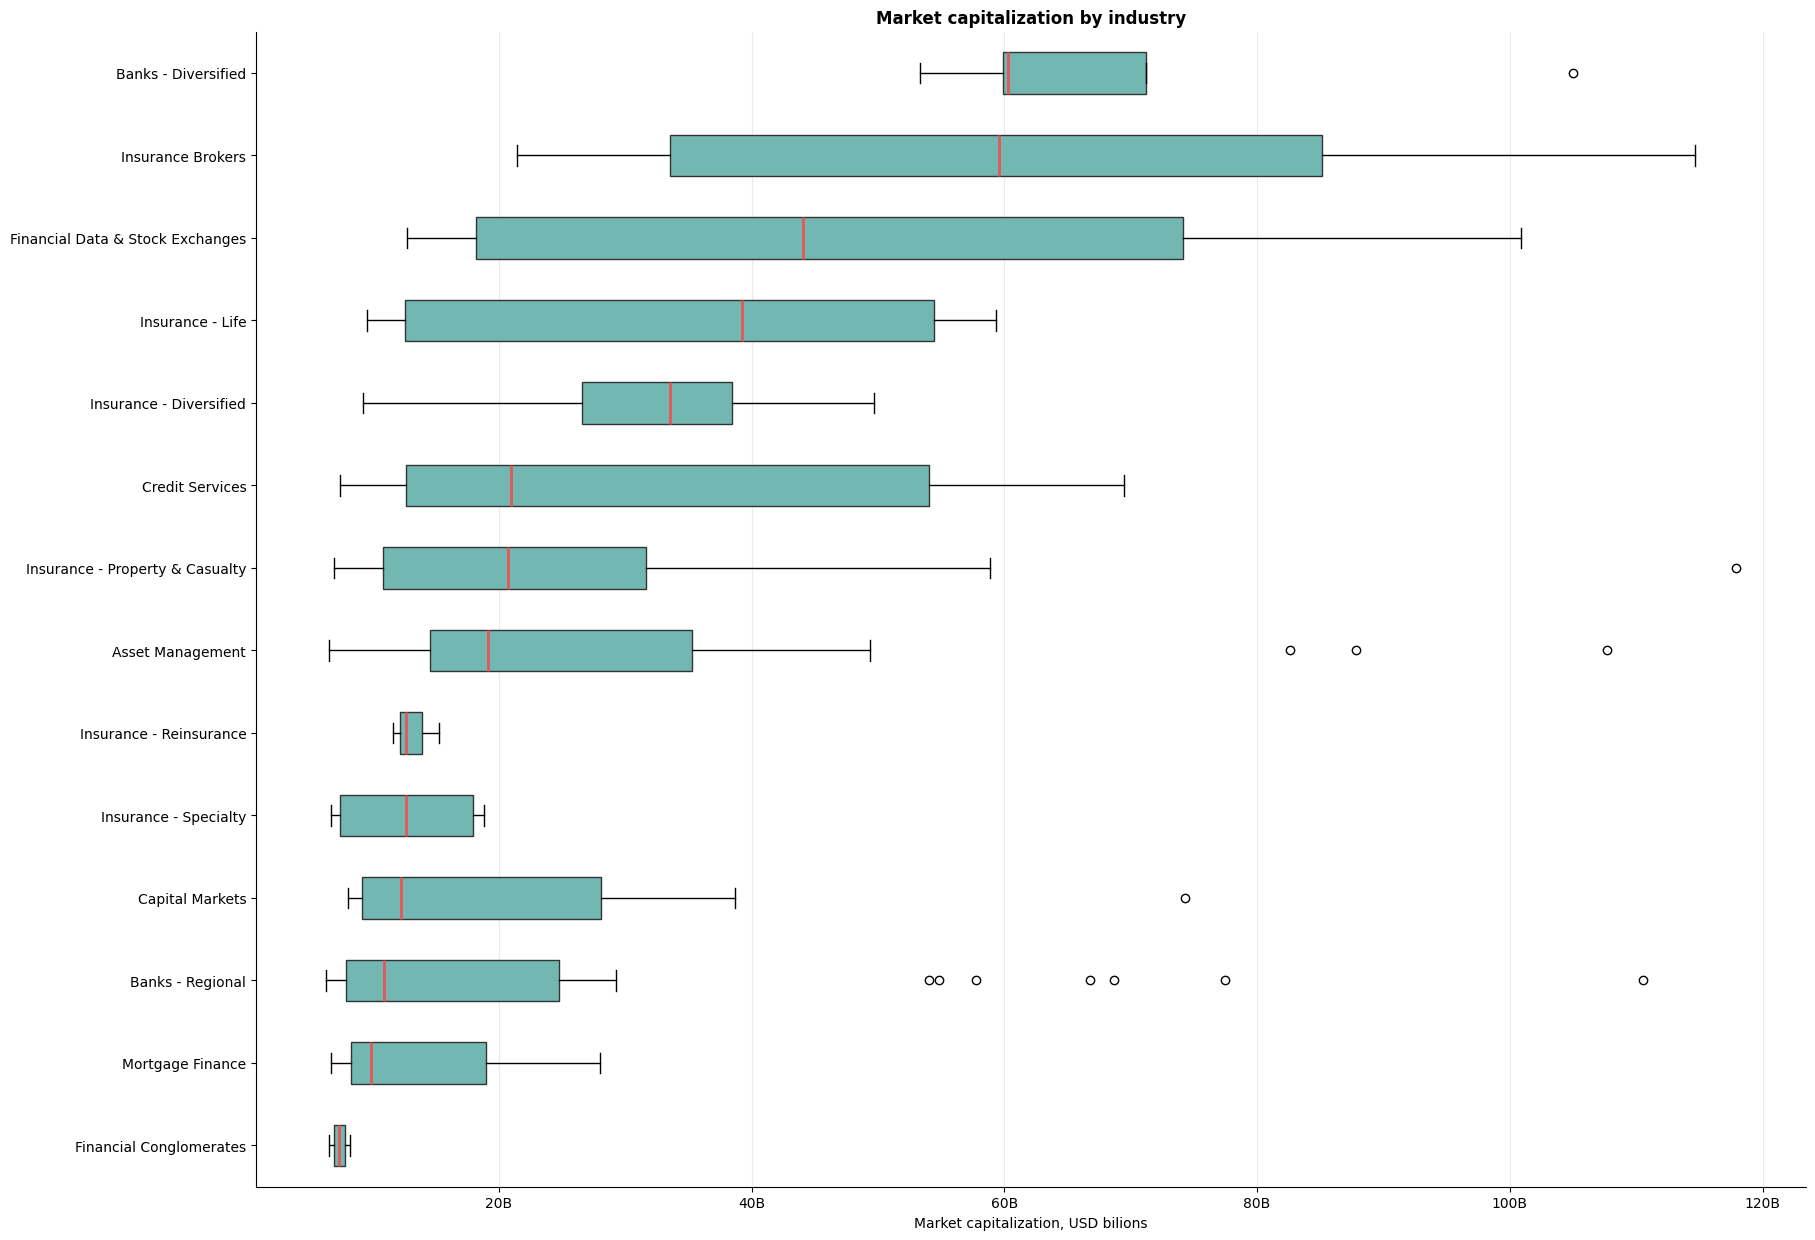

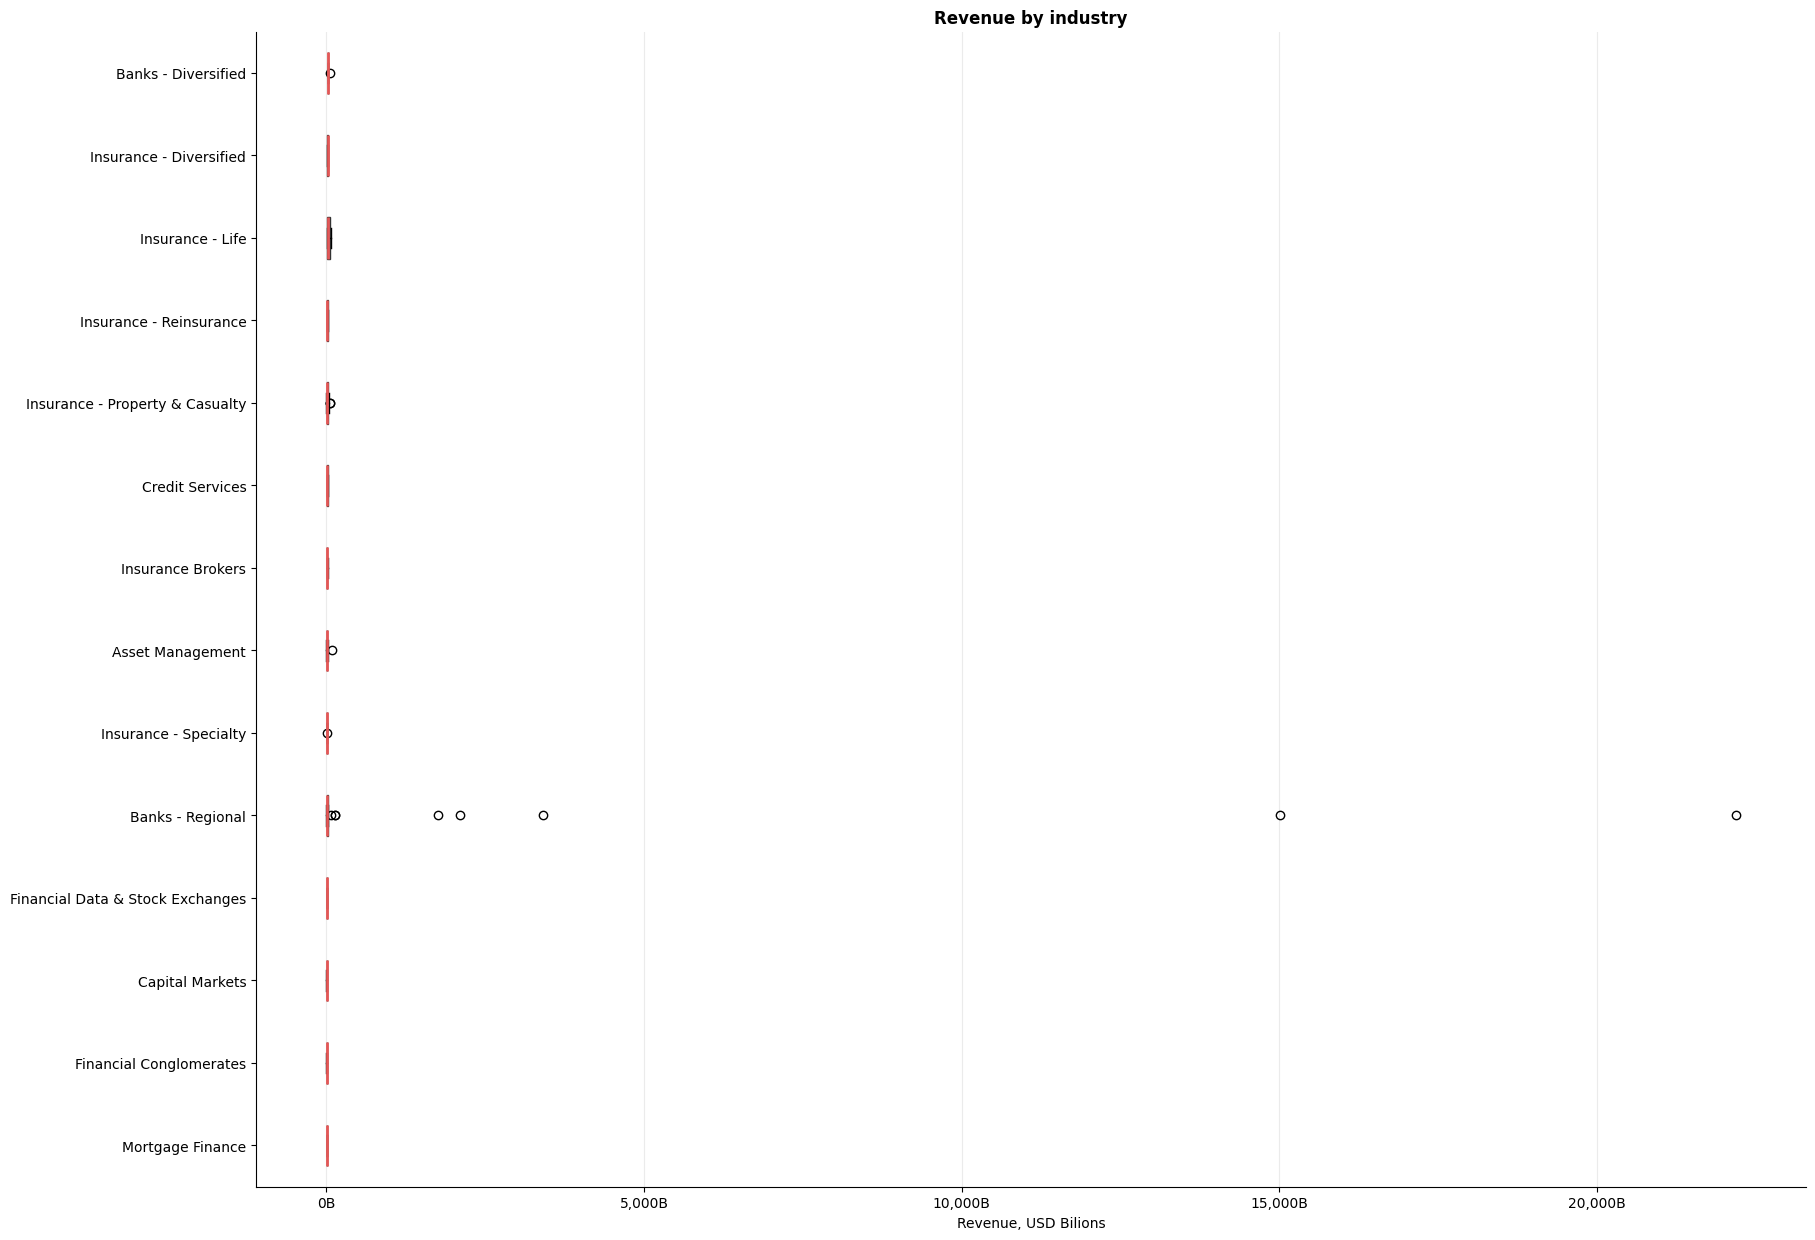

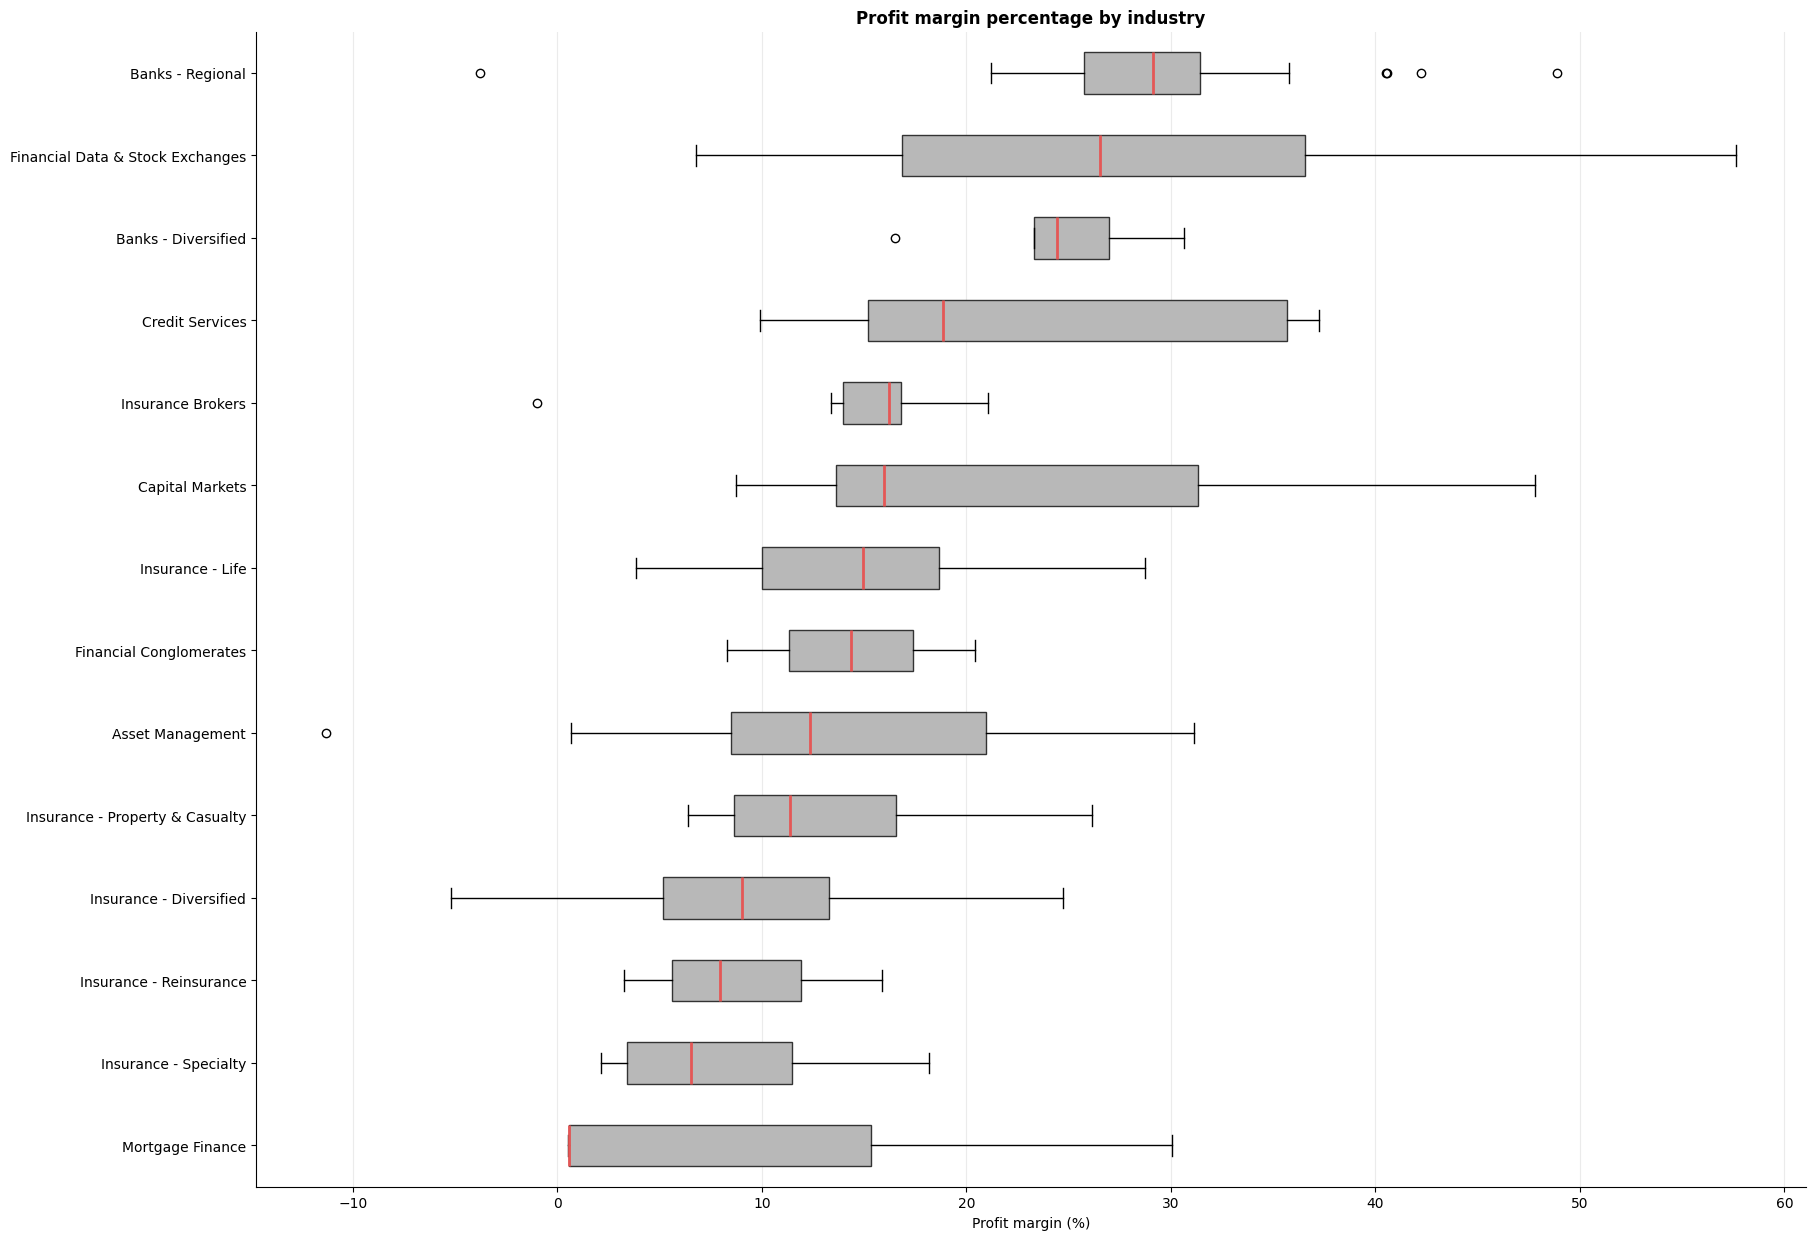

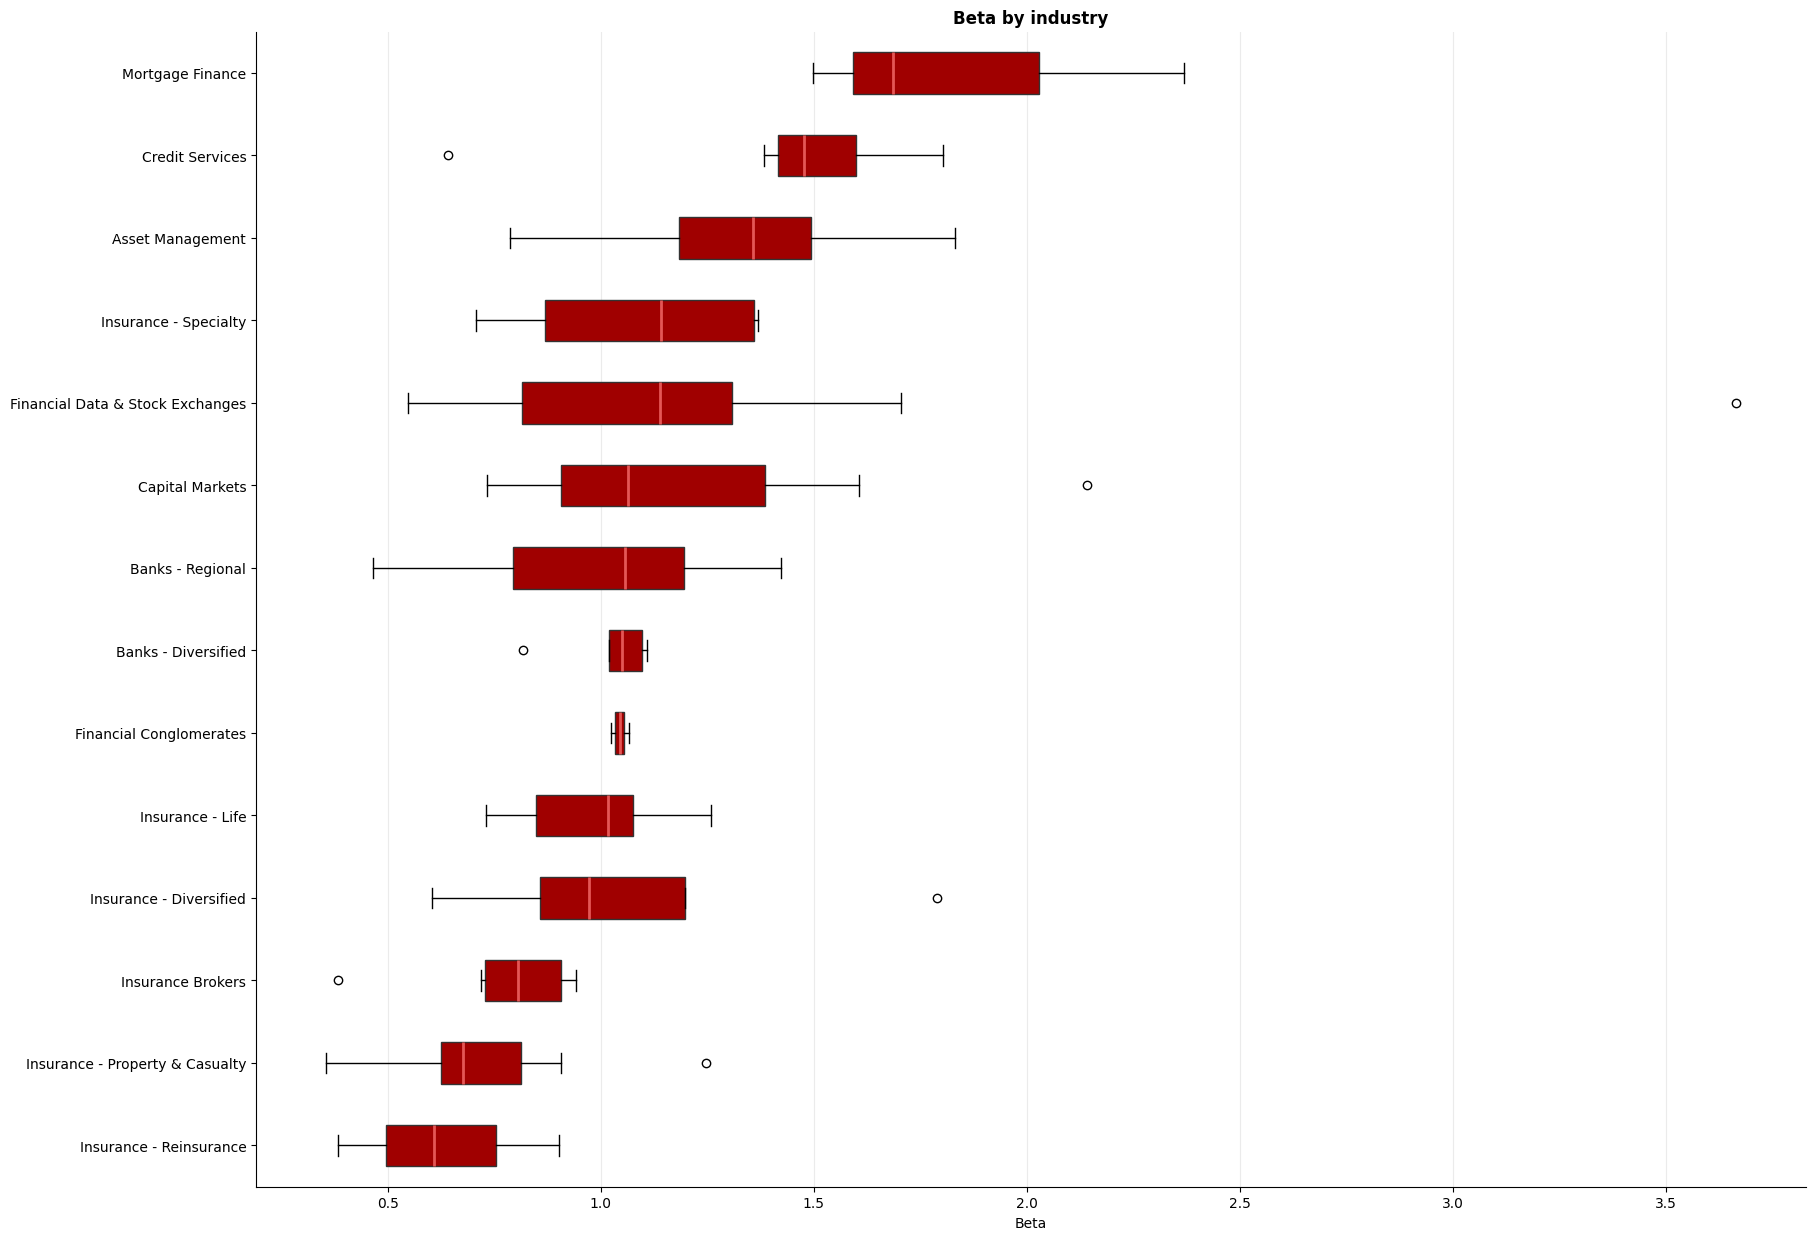

In [8]:
# Creating all the dictionaries that we will use inside the for loop for creating the four plots
# Each dictionary referes to a different part for the plot
industry = {"market_cap_b": 0,
            "revenue_b":0,
            "profit_margin_pct":0,
            "beta":0
}

colors = {"market_cap_b": "#72B7B2",
          "revenue_b":"#4C78A8",
          "profit_margin_pct":"#b8b8b8",
          "beta":"#a00000"
}
                                                                 
xlabel = {"market_cap_b":"Market capitalization, USD bilions", 
          "revenue_b":"Revenue, USD Bilions",                  
          "profit_margin_pct":"Profit margin (%)",
          "beta":"Beta"
}

title = {"market_cap_b":"Market capitalization",
          "revenue_b":"Revenue",
          "profit_margin_pct":"Profit margin percentage",
          "beta":"Beta"

     
}

# we add to the industry dictionary each list of industries ordered by the median for each attribute
for att in industry.keys():
    industry[att] = (df_industry
            .groupby("industry_clean")[att] 
            .median()                       
            .sort_values(ascending=True)
            .index)
    
box_data = {"market_cap_b":0,
            "revenue_b":0,
            "profit_margin_pct":0,
            "beta":0} 

# For each key in the dictionary we have a list of elements for each industry. Each list contains
# a value for each firm. 
for key in box_data.keys():
      box_data[key] = [df_industry.loc[df_industry["industry_clean"] == ind ,key].values for ind in industry[key]] 
      fig, ax = plt.subplots(figsize = (20,15))                                                                    
      ax.boxplot(                                                                                                  
           box_data[key],
           tick_labels = industry[key],
           vert = False,
           patch_artist=True,                                               # Here we create our boxplots 
           boxprops={"facecolor": colors[key], "edgecolor": "#333333"},
           medianprops={"color": "#E45756", "linewidth": 2}
      )
      ax.set_title(title[key]+" by industry")
      ax.set_xlabel(xlabel[key])
      ax.grid(axis="x",alpha = 0.25)
      if key == "market_cap_b" or key == "revenue_b":
          ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter)) 
      clean_spines(ax)



## Step 5

In [9]:
# To have a bettere comparison between industry i will take the top 4 industries in revenue. We can see from the graphs that
# Bank - Regional is an industry with high revenue and the box plot is out of scale, so we want to make a comparison between this indusry and the others 
# To underlying some patterns.
best_ind = industry_summary.sort_values("mean_total_revenue", ascending = False).nlargest(n=4,columns="mean_total_revenue").index
df_top4 = df_industry[(df_industry["industry_clean"] == best_ind[0]) |
                      (df_industry["industry_clean"] == best_ind[1]) |
                      (df_industry["industry_clean"] == best_ind[2]) |
                      (df_industry["industry_clean"] == best_ind[3]) 
                      ].copy()



## Step 6

In the following step, I decided to compare profit vs. revenue to underline whether high revenue necessarily correlates with high profit. Specifically, I want to analyze this relationship for firms within the Regional Banks industry.

The size of the bubbles represents the market cap, while the color gradient indicates the beta.

I have defined the sectors based on thresholds of $100B in revenue and a 20% profit margin. This framework can be used to better evaluate a potential investment.

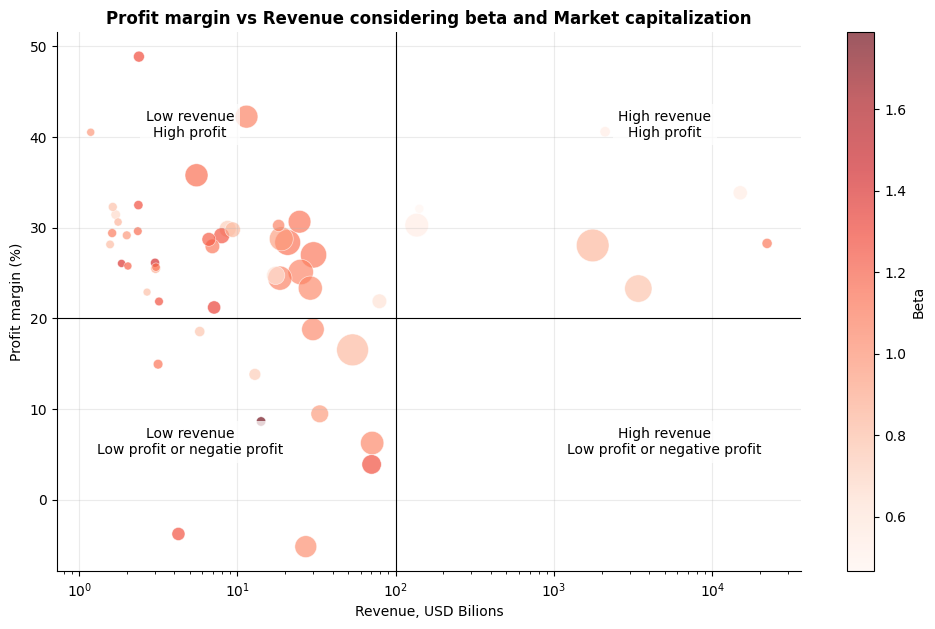

In [10]:
fig, ax = plt.subplots(figsize = (12,7))

# Creating the size of the bubbles
size = (df_top4["market_cap_b"]*5).clip(lower = 20, upper = 700) 

# Creating the plot
points = ax.scatter(
    df_top4["revenue_b"],
    df_top4["profit_margin_pct"],
    s = size,                     
    c = df_top4["beta"],
    cmap="Reds",
    alpha=0.65,
    edgecolors="white",
    linewidths=0.5
)
# We define the four regions
ax.axhline(20, color="black", linewidth=0.8)   
ax.axvline(100, color="black", linewidth=0.8)  

# We define the text for each region
ax.text(5000, 40, "High revenue\nHigh profit", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(5000, 5, "High revenue\nLow profit or negative profit", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(5, 5, "Low revenue\nLow profit or negatie profit", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(5, 40, "Low revenue\nHigh profit", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

# We set the log scale for the x-axis for a better representation
ax.set_xscale("log") 

# We define other properties for the plot
ax.set_title("Profit margin vs Revenue considering beta and Market capitalization")
ax.set_xlabel(xlabel["revenue_b"])
ax.set_ylabel(xlabel["profit_margin_pct"])
ax.grid(alpha=0.25)
clean_spines(ax)

# We add the color bar
cbar = plt.colorbar(points, ax=ax)
cbar.set_label(title["beta"])

plt.show()


## Step 7

To better understand if industries with high revenue and high profit ( Regional Banks) were affected by tensions in the Strait of Hormuz, we will analyze data from yfinance over the last three months.

The baseline has been set using the values from the first day of our period of examination.

[*********************100%***********************]  7 of 7 completed


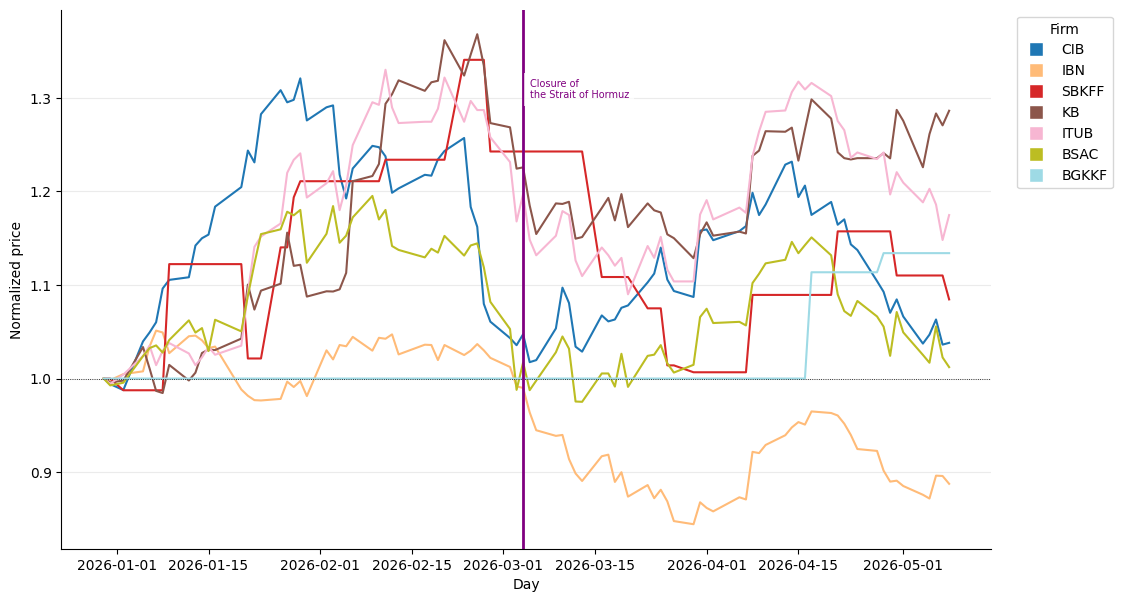

In [59]:
import yfinance as yf
import yfinance.shared as shared
import datetime

# Choosing the high profit/ high revenue data and the top 10 beta values
df_high_r = df_top4[(df_top4["revenue_b"] > 100) & (df_top4["profit_margin_pct"] > 20)].copy() 
df_high_r = df_high_r.nlargest(n=10,columns = "beta")

# Creating a symbol's list for the firm 
tickers = df_high_r["symbol"].tolist()  

# List where append all the legend's elements
legend_handles = []

# Downloading the data and choosing the close price value for each day
data = yf.download(tickers=tickers, period = "90d", interval="1d", auto_adjust=True)
closing_prices = data["Close"]

# Sometimes some firms are not present in the yfinance
# Therefore we erase them form the tickers list
failed = list(shared._ERRORS.keys())
if failed != []:
    for fail in failed:
        tickers.remove(fail)


# Noralizing the data with the first day taken in exam
normalized_prices = closing_prices / closing_prices.iloc[0]

# Creating the palette and assiging each color to a firm
palette = plt.cm.tab20(np.linspace(0,1,len(tickers)))
ticker_color = dict(zip(tickers,palette))

# Creation of the plot and adding each line to the graph
fig, ax = plt.subplots(figsize = (12,7))

for ticker in tickers:
    ax.plot(normalized_prices.index, normalized_prices[ticker],color = ticker_color[ticker])
    legend_handles.append(plt.Line2D([0],[0], marker="s", color = "w", label=ticker,markerfacecolor=ticker_color[ticker], markersize=10))

# Adding the base level and the legend
ax.axhline(1, color="black", linewidth=0.6, linestyle=":")
ax.legend(handles=legend_handles, title="Firm", bbox_to_anchor=(1.02, 1), loc="upper left")

# Adding the vertical line rappresenting the day of the closure of the Hormutz Strait
Hormuz = datetime.datetime(2026,3,4)
Hormuz_text = datetime.datetime(2026,3,5)
ax.axvline(Hormuz, color="purple", linewidth=2, linestyle="-")
ax.text(Hormuz_text, 1.3, "Closure of \nthe Strait of Hormuz", fontsize=7, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"), color = "purple")

clean_spines(ax)
ax.set_ylabel("Normalized price")
ax.set_xlabel("Day")
ax.grid(axis="y",alpha = 0.25)

plt.show()


We observe a medium significant decline following the closure; in fact, prices had already begun to decrease prior to the event. This indicates that the closure directly affect this sector, but bot in a significant way.

## Step 8

For this step I decided to take the top 10 firms with the higher score in beta and a low revenue/high profit score. We want to compare these with the ones of the previous step.

[*******************   40%                       ]  4 of 10 completed$CMA: possibly delisted; no price data found  (period=90d) (Yahoo error = "No data found, symbol may be delisted")
[**********************50%                       ]  5 of 10 completed$SNV: possibly delisted; no price data found  (period=90d) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  10 of 10 completed

2 Failed downloads:
['CMA', 'SNV']: possibly delisted; no price data found  (period=90d) (Yahoo error = "No data found, symbol may be delisted")


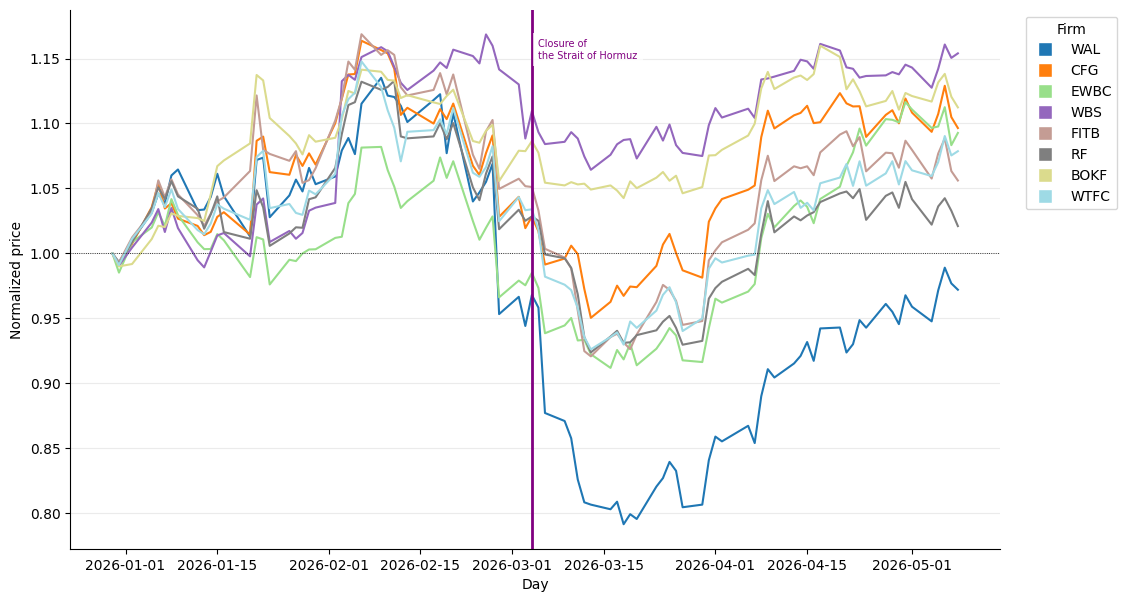

In [58]:
import yfinance as yf
import yfinance.shared as shared
import datetime

# Choosing the low profit/ high revenue data
df_high_r = df_top4[(df_top4["revenue_b"] < 100) & (df_top4["profit_margin_pct"] > 20)].copy() 
df_high_r = df_high_r.nlargest(n=10,columns = "beta")


# Creating a symbol's list for the firm 
tickers = df_high_r["symbol"].tolist()  

# List where append all the legend's elements
legend_handles = []

# Downloading the data and choosing the close price value for each day
data = yf.download(tickers=tickers, period = "90d", interval="1d", auto_adjust=True)
closing_prices = data["Close"]

# Sometimes some firms are not present in the yfinance
# Therefore we erase them form the tickers list
failed = list(shared._ERRORS.keys())
if failed != []:
    for fail in failed:
        tickers.remove(fail)

# Noralizing the data with the first day taken in exam
normalized_prices = closing_prices / closing_prices.iloc[0]

# Creating the palette and assiging each color to a firm
palette = plt.cm.tab20(np.linspace(0,1,len(tickers)))
ticker_color = dict(zip(tickers,palette))

# Creation of the plot and adding each line to the graph
fig, ax = plt.subplots(figsize = (12,7))

for ticker in tickers:
    ax.plot(normalized_prices.index, normalized_prices[ticker],color = ticker_color[ticker])
    legend_handles.append(plt.Line2D([0],[0], marker="s", color = "w", label=ticker,markerfacecolor=ticker_color[ticker], markersize=10))

# Adding the base level and the legend
ax.axhline(1, color="black", linewidth=0.6, linestyle=":")
ax.legend(handles=legend_handles, title="Firm", bbox_to_anchor=(1.02, 1), loc="upper left")

# Adding the vertical line rappresenting the day of the closure of the Hormutz Strait
Hormuz = datetime.datetime(2026,3,4)
Hormuz_text = datetime.datetime(2026,3,5)
ax.axvline(Hormuz, color="purple", linewidth=2, linestyle="-")
ax.text(Hormuz_text, 1.15, "Closure of \nthe Strait of Hormuz", fontsize=7, ha="left", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"), color = "purple")

clean_spines(ax)
ax.set_ylabel("Normalized price")
ax.set_xlabel("Day")
ax.grid(axis="y",alpha = 0.25)

plt.show()


In this case, we observe a more evident downward trend following the closure of the Strait of Hormuz.

Comparing this result with the previous step, it is apparent that the closure significantly impacted the stock prices of firms with lower revenue, whereas firms with higher revenue appeared to be more resilient and were not as affected.

## Final Summary

This Homework analyse the sector of Financial Service. Analising the Mrket capitalization we can see a market concentrated in majority within $200B. After the first step we deccided to erase all the company that have a to high market capitalization, this lead us to a better omogenous disitrubtion of values for this feature.
In step 3 we observe four plots: Market capitalizaiton, Revenue,Profit margin, Beta. In particular we observe higher revenue for the Bank Regional industry. This lead us to a wrong box plot. Nevertless I decided to proced to the subsequent step and compare Revenue with Profit margin, this to see if industry in high revenue means high profit margin.
From the bubble chart we can observe that for firms in this industry the answer is yes and also have low risk in investiment. We can also obsere that the majority of firms have low ravenue, but high profit margin, the beta value in this case is heteroginous. We can observe data also in the low revenue/low profit industries, but there are not firms with high revenue/low profit. All sugest us that an investiments in the Regional Bank sector (high revenue/high profit) are sujested.
In the final steps we analyse the price during the previous 3 month